In [1]:
from importlib.util import find_spec
from pathlib import Path

import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

DATA_DIR = Path("project")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

CHART_CONFIG = {
    "displaylogo": False,
    "responsive": True,
}

print("Plotly version:", plotly.__version__)

Plotly version: 6.8.0


In [2]:
new_car_basics=pd.read_csv(DATA_DIR/"car data.csv")

In [3]:
new_car_basics.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
new_car_basics["Selling_Price"]=(new_car_basics["Selling_Price"]*100000).round().astype('Int64')
new_car_basics["Present_Price"]=(new_car_basics["Present_Price"]*100000).round().astype('Int64')

In [5]:
new_car_basics.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,335000,559000,27000,Petrol,Dealer,Manual,0
1,sx4,2013,475000,954000,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,725000,985000,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,285000,415000,5200,Petrol,Dealer,Manual,0
4,swift,2014,460000,687000,42450,Diesel,Dealer,Manual,0


In [6]:
new_car_basics.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [7]:
new_car_basics['Car_Name'] = new_car_basics['Car_Name'].str.strip().str.title()

In [8]:
current_year = 2026
new_car_basics['Car_Age'] = current_year - new_car_basics['Year']
new_car_basics['Price_Difference'] = new_car_basics['Present_Price'] - new_car_basics['Selling_Price']
new_car_basics['Depreciation_Pct'] = (
    (new_car_basics['Present_Price'] - new_car_basics['Selling_Price']) / new_car_basics['Present_Price']) * 100

In [9]:
new_car_basics.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Price_Difference,Depreciation_Pct
0,Ritz,2014,335000,559000,27000,Petrol,Dealer,Manual,0,12,224000,40.071556
1,Sx4,2013,475000,954000,43000,Diesel,Dealer,Manual,0,13,479000,50.209644
2,Ciaz,2017,725000,985000,6900,Petrol,Dealer,Manual,0,9,260000,26.395939
3,Wagon R,2011,285000,415000,5200,Petrol,Dealer,Manual,0,15,130000,31.325301
4,Swift,2014,460000,687000,42450,Diesel,Dealer,Manual,0,12,227000,33.042213


In [10]:
new_car_basics.duplicated().value_counts()

False    299
True       2
Name: count, dtype: int64

In [11]:
car_market_details=pd.read_csv(DATA_DIR/"CAR DETAILS FROM CAR DEKHO.csv")

In [12]:
car_market_details=car_market_details.rename(columns={"year":"Year"})
car_market_details=car_market_details.rename(columns={"name":"Car_Name"})

In [13]:
car_market_details.head(5)

,Car_Name,Year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [14]:
duplicates=car_market_details[car_market_details.duplicated().eq(True)]

In [15]:
print(duplicates)

                             Car_Name  Year  selling_price  km_driven    fuel  \
13                      Maruti 800 AC  2007          60000      70000  Petrol   
14           Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
15               Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
16             Datsun RediGO T Option  2017         250000      46000  Petrol   
17              Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   
...                               ...   ...            ...        ...     ...   
4307                 Mahindra Xylo H4  2019         599000      15000  Diesel   
4308              Maruti Alto 800 LXI  2018         200000      35000  Petrol   
4309                 Datsun GO Plus T  2017         350000      10171  Petrol   
4310  Renault Duster 110PS Diesel RxL  2015         465000      41123  Diesel   
4311          Toyota Camry Hybrid 2.5  2017        1900000      20118  Petrol   

     seller_type transmissi

In [16]:
clean_car_market_details=car_market_details.drop_duplicates().copy()

In [17]:
clean_car_market_details.duplicated().value_counts()

False    3577
Name: count, dtype: int64

In [18]:
clean_car_market_details.isna().sum()

Car_Name         0
Year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [19]:
current_year = 2026
clean_car_market_details['Car_Age'] = current_year - clean_car_market_details['Year']

In [20]:
clean_car_market_details=clean_car_market_details.rename(columns={"year":"Year"})


In [21]:
clean_car_market_details.head(5)

,Car_Name,Year,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [22]:
car_performance=pd.read_csv(DATA_DIR/"Car details v3.csv")

In [23]:
car_performance=car_performance.rename(columns={"name":"Car_Name"})

In [24]:
car_performance.head(5)

,Car_Name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [25]:
car_performance.isna().sum()

Car_Name           0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [26]:
car_performance.dtypes

Car_Name             str
year               int64
selling_price      int64
km_driven          int64
fuel                 str
seller_type          str
transmission         str
owner                str
mileage              str
engine               str
max_power            str
torque               str
seats            float64
dtype: object

In [27]:
car_performance["mileage"]=car_performance["mileage"].astype(str).replace("kmpl","",regex=False).str.strip()

In [28]:
car_performance["mileage"]=car_performance["mileage"].str.extract(r'([\d.]+)').astype(float)

In [29]:
car_performance["mileage"]=car_performance["mileage"].fillna(car_performance["mileage"].median())

In [30]:
car_performance["engine"]=car_performance["engine"].astype(str).str.extract(r'([\d.]+)').astype(float)
car_performance["engine"]=car_performance["engine"].fillna(car_performance["engine"].median())
car_performance["engine"]=car_performance["engine"].astype(int)

In [31]:
car_performance["max_power"]=car_performance["max_power"].astype(str).str.extract(r'([\d.]+)').astype(float)
car_performance["max_power"]=car_performance["max_power"].fillna(car_performance["max_power"].median())
car_performance["max_power"]=car_performance["max_power"].astype(int)

In [32]:
car_performance["torque"]=car_performance["torque"].astype(str).str.extract(r'([\d.]+)').astype(float)
car_performance["torque"]=car_performance["torque"].fillna(car_performance["torque"].median())
car_performance["torque"]=car_performance["torque"].astype(int)

In [33]:
car_performance["seats"]=car_performance["seats"].astype(str).str.extract(r'([\d.]+)').astype(float)
car_performance["seats"]=car_performance["seats"].fillna(car_performance["seats"].median())

In [34]:
car_performance.isna().sum()

Car_Name         0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

In [35]:
current_year = 2026
car_performance['Car_Age'] = current_year - car_performance['year']

In [36]:
car_performance=car_performance.rename(columns={'year':"Year"})

In [37]:
car_performance.head(5)

,Car_Name,Year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Car_Age
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74,190,5.0,12
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103,250,5.0,12
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78,12,5.0,20
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90,22,5.0,16
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88,11,5.0,19


In [38]:
car_dimensions=pd.read_csv(DATA_DIR/"car details v4.csv")

In [39]:
clean_car_dimensions=car_dimensions.copy()

In [40]:
clean_car_dimensions["Car_Name"]=clean_car_dimensions["Make"]+" "+clean_car_dimensions["Model"]

In [41]:
clean_car_dimensions=clean_car_dimensions.drop(columns=["Make","Model"])

In [42]:
col=clean_car_dimensions.pop("Car_Name")
clean_car_dimensions.insert(0,"Car_Name",col)

In [43]:
clean_car_dimensions.head(5)

,Car_Name,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [44]:
clean_car_dimensions["Car_Name"]

0                        Honda Amaze 1.2 VX i-VTEC
1                    Maruti Suzuki Swift DZire VDI
2                     Hyundai i10 Magna 1.2 Kappa2
3                                  Toyota Glanza G
4           Toyota Innova 2.4 VX 7 STR [2016-2020]
                           ...                    
2054                Mahindra XUV500 W8 [2015-2017]
2055                          Hyundai Eon D-Lite +
2056              Ford Figo Duratec Petrol ZXI 1.2
2057     BMW 5-Series 520d Luxury Line [2017-2019]
2058    Mahindra Bolero Power Plus ZLX [2016-2019]
Name: Car_Name, Length: 2059, dtype: str

In [45]:
clean_car_dimensions.isna().sum()

Car_Name                0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [46]:
clean_car_dimensions.dtypes

Car_Name                  str
Price                   int64
Year                    int64
Kilometer               int64
Fuel Type                 str
Transmission              str
Location                  str
Color                     str
Owner                     str
Seller Type               str
Engine                    str
Max Power                 str
Max Torque                str
Drivetrain                str
Length                float64
Width                 float64
Height                float64
Seating Capacity      float64
Fuel Tank Capacity    float64
dtype: object

In [47]:
clean_car_dimensions["Engine"].unique()

<StringArray>
['1198 cc', '1248 cc', '1197 cc', '2393 cc', '1373 cc', '1991 cc', '1995 cc',
 '1798 cc', '1461 cc',  '999 cc',
 ...
 '2998 cc', '2198 cc', '2157 cc', '1595 cc', '1586 cc',  '936 cc', '1332 cc',
 '2400 cc',  '793 cc',  '995 cc']
Length: 109, dtype: str

In [48]:
clean_car_dimensions["Engine"]=clean_car_dimensions["Engine"].astype(str).str.extract(r'([\d.]+)').astype(float)
clean_car_dimensions["Engine"]=clean_car_dimensions["Engine"].astype('Int64')
clean_car_dimensions["Engine"]=clean_car_dimensions["Engine"].fillna(clean_car_dimensions["Engine"].median()).astype('Int64')


In [49]:
clean_car_dimensions["Max Power"]=clean_car_dimensions["Max Power"].astype(str).str.extract(r'([\d.]+)').astype(float)
clean_car_dimensions["Max Power"]=clean_car_dimensions["Max Power"].fillna(clean_car_dimensions["Max Power"].median())
clean_car_dimensions["Max Power"]=clean_car_dimensions["Max Power"].astype(int)

In [50]:
clean_car_dimensions["Max Torque"]=clean_car_dimensions["Max Torque"].astype(str).str.extract(r'([\d.]+)').astype(float)
clean_car_dimensions["Max Torque"]=clean_car_dimensions["Max Torque"].fillna(clean_car_dimensions["Max Torque"].median())
clean_car_dimensions["Max Torque"]=clean_car_dimensions["Max Torque"].astype(int)

In [51]:
clean_car_dimensions["Length"]=clean_car_dimensions["Length"].astype(str).str.extract(r'([\d.]+)').astype(float)
clean_car_dimensions["Length"]=clean_car_dimensions["Length"].fillna(clean_car_dimensions["Length"].median())
clean_car_dimensions["Length"]=clean_car_dimensions["Length"].astype('Int64')

In [52]:
clean_car_dimensions["Width"]=clean_car_dimensions["Width"].astype(str).str.extract(r'([\d.]+)').astype(float)
clean_car_dimensions["Width"]=clean_car_dimensions["Width"].fillna(clean_car_dimensions["Width"].median())
clean_car_dimensions["Width"]=clean_car_dimensions["Width"].astype('Int64')

In [53]:
clean_car_dimensions["Height"]=clean_car_dimensions["Height"].astype(str).str.extract(r'([\d.]+)').astype(float)
clean_car_dimensions["Height"]=clean_car_dimensions["Height"].fillna(clean_car_dimensions["Height"].median())
clean_car_dimensions["Height"]=clean_car_dimensions["Height"].astype('Int64')

In [54]:
clean_car_dimensions["Seating Capacity"]=clean_car_dimensions["Seating Capacity"].astype(str).str.extract(r'([\d.]+)').astype(float)
clean_car_dimensions["Seating Capacity"]=clean_car_dimensions["Seating Capacity"].fillna(clean_car_dimensions["Seating Capacity"].median())
clean_car_dimensions["Seating Capacity"]=clean_car_dimensions["Seating Capacity"].astype('Int64')

In [55]:
clean_car_dimensions["Fuel Tank Capacity"]=clean_car_dimensions["Fuel Tank Capacity"].astype(str).str.extract(r'([\d.]+)').astype(float)
clean_car_dimensions["Fuel Tank Capacity"]=clean_car_dimensions["Fuel Tank Capacity"].fillna(clean_car_dimensions["Fuel Tank Capacity"].median())
clean_car_dimensions["Fuel Tank Capacity"]=clean_car_dimensions["Fuel Tank Capacity"].astype(int)

In [56]:
current_year = 2026
clean_car_dimensions['Car_Age'] = current_year - clean_car_dimensions['Year']

In [57]:
most_frequent=clean_car_dimensions['Drivetrain'].mode()[0]
clean_car_dimensions['Drivetrain']=clean_car_dimensions['Drivetrain'].fillna(most_frequent)

In [58]:
clean_car_dimensions.isna().sum()

Car_Name              0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
Car_Age               0
dtype: int64

In [59]:
car_dimensions["Drivetrain"].unique()

<StringArray>
['FWD', 'RWD', 'AWD', nan]
Length: 4, dtype: str

In [60]:
clean_car_dimensions.head(6)

,Car_Name,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Car_Age
0,Honda Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198,87,109,FWD,3990,1680,1505,5,35,9
1,Maruti Suzuki Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248,74,190,FWD,3995,1695,1555,5,42,12
2,Hyundai i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197,79,112,FWD,3585,1595,1550,5,35,15
3,Toyota Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197,82,113,FWD,3995,1745,1510,5,37,7
4,Toyota Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393,148,343,RWD,4735,1830,1795,7,55,8
5,Maruti Suzuki Ciaz ZXi,675000,2017,73315,Petrol,Manual,Pune,Grey,First,Individual,1373,91,130,FWD,4490,1730,1485,5,43,9


In [61]:
clean_car_dimensions.columns.tolist()

['Car_Name',
 'Price',
 'Year',
 'Kilometer',
 'Fuel Type',
 'Transmission',
 'Location',
 'Color',
 'Owner',
 'Seller Type',
 'Engine',
 'Max Power',
 'Max Torque',
 'Drivetrain',
 'Length',
 'Width',
 'Height',
 'Seating Capacity',
 'Fuel Tank Capacity',
 'Car_Age']

In [62]:
car_performance.columns.tolist()

['Car_Name',
 'Year',
 'selling_price',
 'km_driven',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'mileage',
 'engine',
 'max_power',
 'torque',
 'seats',
 'Car_Age']

In [63]:
car_performance=car_performance.rename(columns={'selling_price':"Price"})
car_performance=car_performance.rename(columns={'km_driven':"Kilometer"})
car_performance=car_performance.rename(columns={'fuel':"Fuel Type"})
car_performance=car_performance.rename(columns={'seller_type':"Seller Type"})
car_performance=car_performance.rename(columns={'transmission':"Transmission"})
car_performance=car_performance.rename(columns={'owner':"Owner"})
car_performance=car_performance.rename(columns={'seats':"Seating Capacity"})
car_performance=car_performance.rename(columns={'max_power':"Max Power"})
car_performance=car_performance.rename(columns={'torque':"Max Torque"})
car_performance=car_performance.rename(columns={'engine':"Engine"})

In [64]:
clean_car_dimensions.columns.tolist()

['Car_Name',
 'Price',
 'Year',
 'Kilometer',
 'Fuel Type',
 'Transmission',
 'Location',
 'Color',
 'Owner',
 'Seller Type',
 'Engine',
 'Max Power',
 'Max Torque',
 'Drivetrain',
 'Length',
 'Width',
 'Height',
 'Seating Capacity',
 'Fuel Tank Capacity',
 'Car_Age']

In [65]:
car_performance.columns.tolist()

['Car_Name',
 'Year',
 'Price',
 'Kilometer',
 'Fuel Type',
 'Seller Type',
 'Transmission',
 'Owner',
 'mileage',
 'Engine',
 'Max Power',
 'Max Torque',
 'Seating Capacity',
 'Car_Age']

In [66]:
car_performance.dtypes

Car_Name                str
Year                  int64
Price                 int64
Kilometer             int64
Fuel Type               str
Seller Type             str
Transmission            str
Owner                   str
mileage             float64
Engine                int64
Max Power             int64
Max Torque            int64
Seating Capacity    float64
Car_Age               int64
dtype: object

In [67]:
clean_car_dimensions.dtypes

Car_Name                str
Price                 int64
Year                  int64
Kilometer             int64
Fuel Type               str
Transmission            str
Location                str
Color                   str
Owner                   str
Seller Type             str
Engine                Int64
Max Power             int64
Max Torque            int64
Drivetrain              str
Length                Int64
Width                 Int64
Height                Int64
Seating Capacity      Int64
Fuel Tank Capacity    int64
Car_Age               int64
dtype: object

In [68]:
car_performance.columns=car_performance.columns.str.strip()
clean_car_dimensions.columns=clean_car_dimensions.columns.str.strip()

In [69]:
car_dim_year=clean_car_dimensions.groupby(["Year","Fuel Type"],as_index=False).agg(
    Fuel_Capacity=("Fuel Tank Capacity","mean"),
    Kilometer=("Kilometer","mean"),
)

In [70]:
car_dim_year.head(5)

,Year,Fuel Type,Fuel_Capacity,Kilometer
0,1988,Petrol,80.0,71000.0
1,1996,Petrol + LPG,50.0,100000.0
2,2000,Petrol,50.0,65000.0
3,2002,Petrol,50.0,65494.0
4,2004,Petrol,50.0,65082.0


In [71]:
car_performance_year=car_performance.groupby(["Year","Fuel Type"],as_index=False).agg(
    Price=("Price","mean"),
    MaxPower=("Max Power","mean"),
    MaxTorque=("Max Torque","mean"),
)

In [72]:
car_performance_year.head(5)

,Year,Fuel Type,Price,MaxPower,MaxTorque
0,1983,Diesel,300000.0,82.0,154.0
1,1991,LPG,55000.0,82.0,154.0
2,1994,Diesel,109500.0,67.0,130.0
3,1994,Petrol,45000.0,37.0,59.0
4,1995,Diesel,160000.0,82.0,154.0


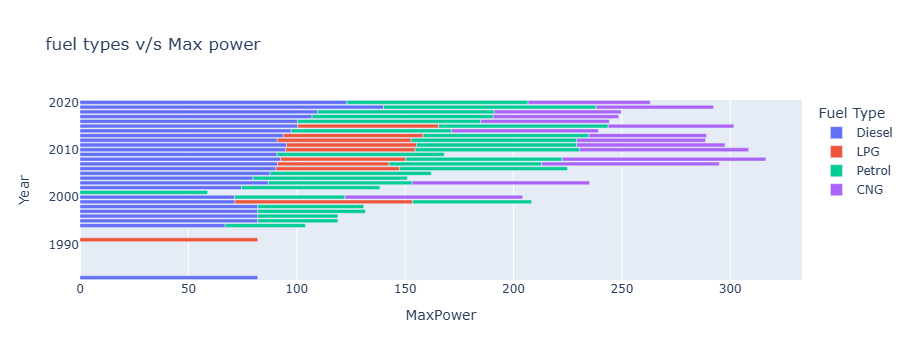

In [73]:
figure = px.bar(
    car_performance_year,
    x="MaxPower",
    y="Year",
    color="Fuel Type",
    orientation="h",
    title="fuel types v/s Max power",
)

figure.show()

In [74]:
car_performance["Fuel Type"].unique()

<StringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

In [75]:
fuel_counts = (
    car_performance_year["Fuel Type"]
    .value_counts()
    .rename_axis("Fuel_Type")
    .reset_index(name="Year")
)

print(fuel_counts.to_string(index=False))

Fuel_Type  Year
   Diesel    27
   Petrol    27
      CNG    15
      LPG    10


In [76]:
fuel_counts = (
    car_dim_year["Fuel Type"]
    .value_counts()
    .rename_axis("Fuel_Type")
    .reset_index(name="Year")
)

print(fuel_counts.to_string(index=False))

   Fuel_Type  Year
      Petrol    21
      Diesel    16
         CNG    13
         LPG     4
    Electric     3
      Hybrid     2
Petrol + LPG     1
   CNG + CNG     1
Petrol + CNG     1


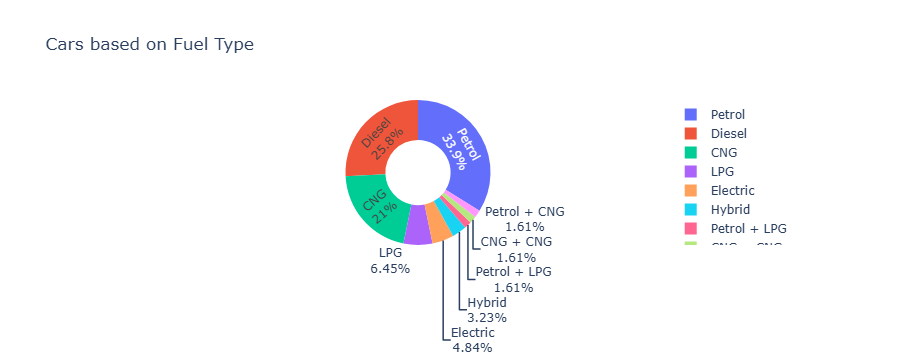

In [77]:
carfuel_donut = px.pie(
    fuel_counts,
    names="Fuel_Type",
    values="Year",
    hole=0.45,
    title="Cars based on Fuel Type",
    template="plotly_white",
)
carfuel_donut.update_traces(textinfo="label+percent")

carfuel_donut.show(config=CHART_CONFIG)

In [78]:
cars_2015 = clean_car_dimensions[clean_car_dimensions["Year"]==2015].copy()
location_summary = (
    cars_2015.groupby(["Location"], as_index=False)
    .agg(car_counts=("Location", "count"),
        )
    .sort_values("car_counts",ascending=False)
)

print(location_summary.round(20).to_string(index=False))

    Location  car_counts
      Mumbai          38
       Delhi          20
        Pune          11
     Kolkata           9
   Ahmedabad           7
      Mohali           7
   Faridabad           6
   Bangalore           5
     Chennai           5
   Hyderabad           5
     Gurgaon           5
 Navi Mumbai           4
       Patna           4
      Jaipur           4
        Agra           4
      Kanpur           4
      Ranchi           4
  Chandigarh           3
    Ludhiana           3
    Varanasi           3
     Lucknow           3
      Raipur           3
    Dehradun           2
  Coimbatore           2
       Noida           2
     Roorkee           2
   Allahabad           1
Ambala Cantt           1
      Kollam           1
  Jamshedpur           1
      Indore           1
      Meerut           1
      Mysore           1
      Purnea           1
       Surat           1
       Thane           1
       Udupi           1
 Yamunanagar           1
    Zirakpur           1


In [79]:
top_locations=location_summary[location_summary["car_counts"]>5]
top_locations

,Location,car_counts
23,Mumbai,38
9,Delhi,20
28,Pune,11
17,Kolkata,9
1,Ahmedabad,7
22,Mohali,7
10,Faridabad,6


In [80]:
cars_merge = car_dim_year.merge(
    car_performance_year,
    on=["Year","Fuel Type"],
    validate="one_to_one",
    suffixes=("_dimension","_performance")
)

In [81]:
cars_merge.head(5)

,Year,Fuel Type,Fuel_Capacity,Kilometer,Price,MaxPower,MaxTorque
0,2000,Petrol,50.0,65000.0,71208.142857,50.928571,77.642857
1,2002,Petrol,50.0,65494.0,87695.652174,63.869565,90.695652
2,2004,Petrol,50.0,65082.0,102697.100000,71.180000,82.160000
3,2006,Petrol,54.0,124650.0,136288.179775,77.471910,76.134831
4,2007,Diesel,60.0,92170.0,233868.958904,91.178082,106.246575


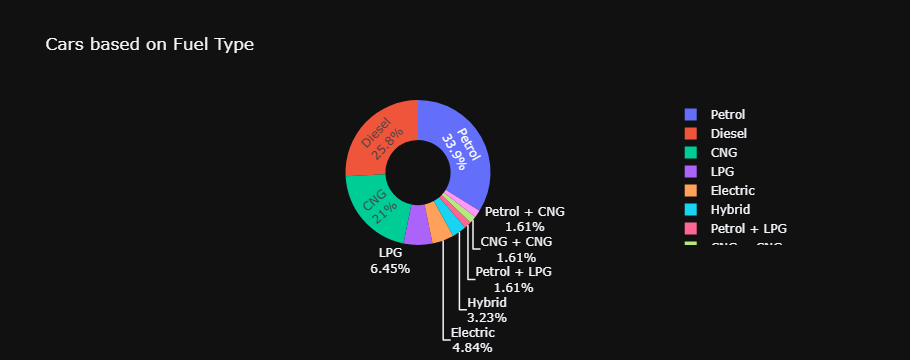

In [82]:
carfuel_donut = px.pie(
    fuel_counts,
    names="Fuel_Type",
    values="Year",
    hole=0.45,
    title="Cars based on Fuel Type",
    template="plotly_dark",
)
carfuel_donut.update_traces(textinfo="label+percent")

carfuel_donut.show(config=CHART_CONFIG)

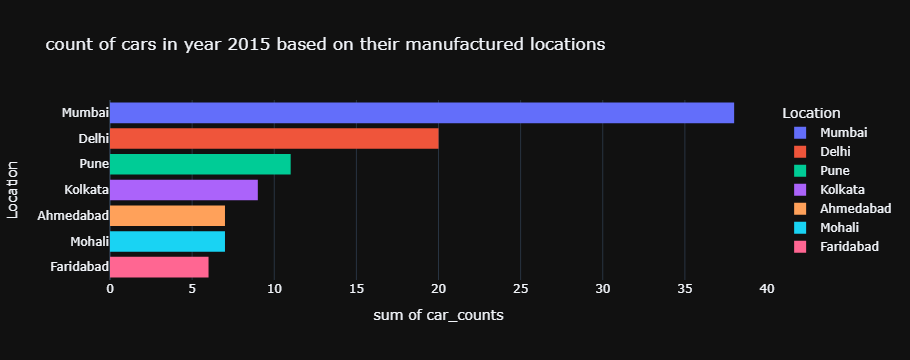

In [83]:
location_bar = px.histogram(
    top_locations,
    x="car_counts",
    y="Location",
    color="Location",
    orientation="h",
    title="count of cars in year 2015 based on their manufactured locations",
    template="plotly_dark",
)

location_bar.show(config=CHART_CONFIG)

In [84]:
cars_merge = cars_merge.sort_values(["Year"]).reset_index(drop=True)

In [85]:
cars_merge.head(5)

,Year,Fuel Type,Fuel_Capacity,Kilometer,Price,MaxPower,MaxTorque
0,2000,Petrol,50.0,65000.0,71208.142857,50.928571,77.642857
1,2002,Petrol,50.0,65494.0,87695.652174,63.869565,90.695652
2,2004,Petrol,50.0,65082.0,102697.100000,71.180000,82.160000
3,2006,Petrol,54.0,124650.0,136288.179775,77.471910,76.134831
4,2007,Diesel,60.0,92170.0,233868.958904,91.178082,106.246575


In [86]:
cars_merge.shape

(44, 7)

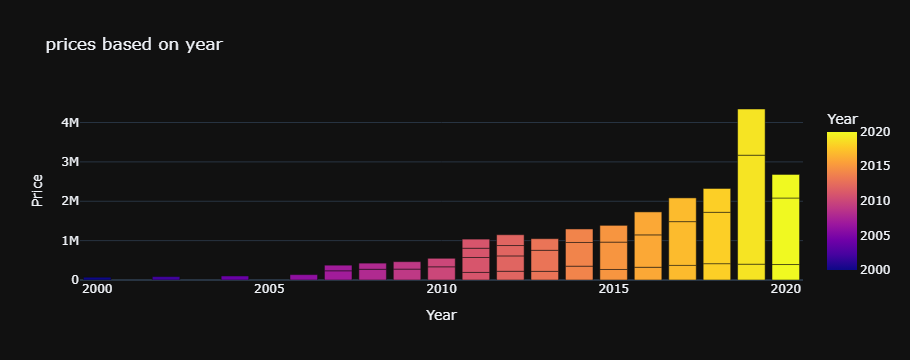

In [87]:
fig = px.bar(
    cars_merge,
    x="Year",
    y="Price",
    orientation="v",
    title="prices based on year",
    color="Year",
    template="plotly_dark")

fig.show()

In [88]:
import numpy as np
filtered_cars = car_performance[
    (car_performance['Price'] < 500000) & 
    (car_performance['Kilometer'] < 300000)
].copy()
filtered_cars['Price_Lakhs'] = filtered_cars['Price'] / 100000
filtered_cars['Kilometer_Lakhs'] = filtered_cars['Kilometer'] / 100000



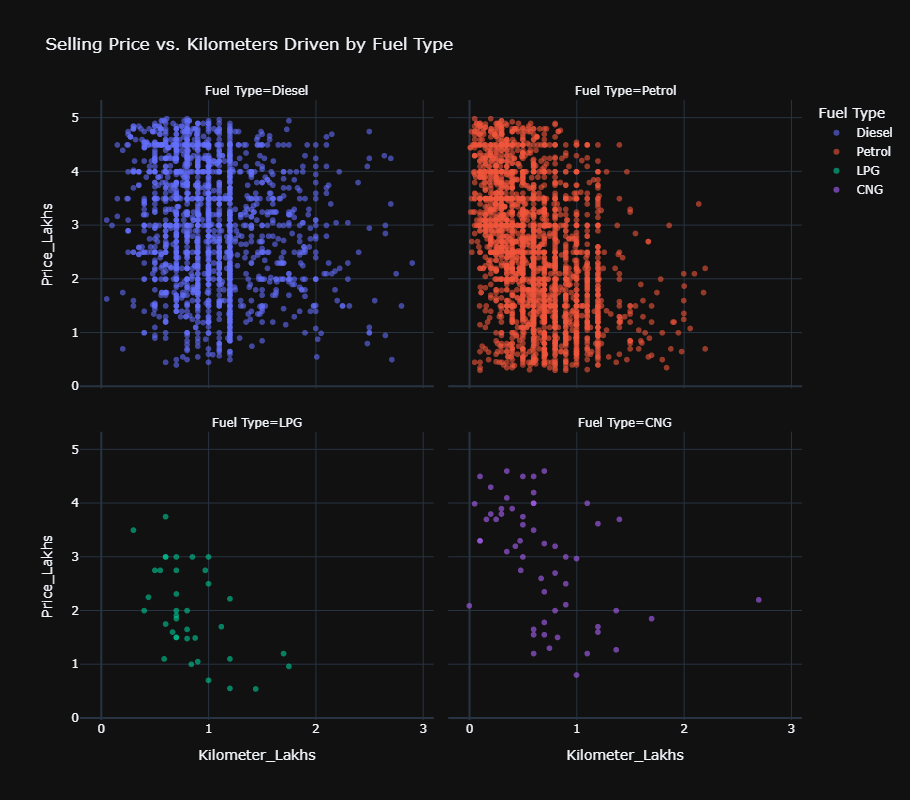

In [89]:

price_changes=px.scatter(
    data_frame=filtered_cars,
    x='Kilometer_Lakhs', 
    y='Price_Lakhs',
    color='Fuel Type', 
    hover_name='Car_Name',
    facet_col='Fuel Type',
    facet_col_wrap=2,
    height=800,
    template="plotly_dark",
    opacity=0.6,
    title=('Selling Price vs. Kilometers Driven by Fuel Type'),
    labels={
        'Kilometer':'Kilometers Driven',
        'Price':'Selling Price (Lakhs INR)'}
   )

price_changes.update_traces(marker=dict(size=6))
price_changes.show()

In [90]:
new_car_basics.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Price_Difference,Depreciation_Pct
0,Ritz,2014,335000,559000,27000,Petrol,Dealer,Manual,0,12,224000,40.071556
1,Sx4,2013,475000,954000,43000,Diesel,Dealer,Manual,0,13,479000,50.209644
2,Ciaz,2017,725000,985000,6900,Petrol,Dealer,Manual,0,9,260000,26.395939
3,Wagon R,2011,285000,415000,5200,Petrol,Dealer,Manual,0,15,130000,31.325301
4,Swift,2014,460000,687000,42450,Diesel,Dealer,Manual,0,12,227000,33.042213


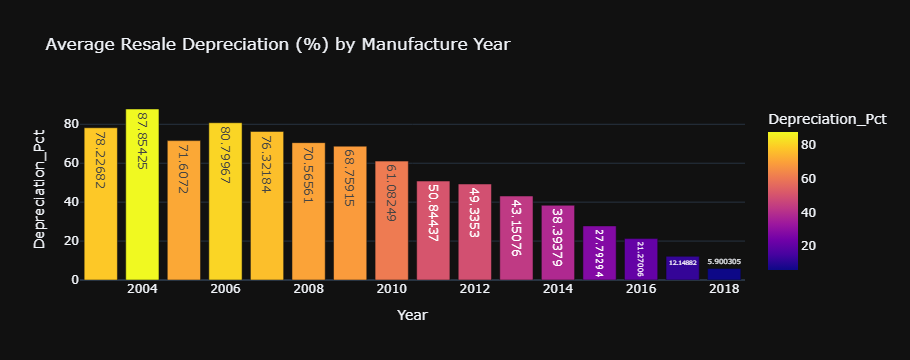

In [91]:
#Average Depreciation Percentage by Year (from v1)
#figax = plt.subplots(figsize=(8, 5))
dep_by_year = new_car_basics.groupby('Year')['Depreciation_Pct'].mean().reset_index().sort_values(by="Depreciation_Pct",ascending=True)

dep_by_bar = px.bar(
    dep_by_year,
    x="Year",
    y="Depreciation_Pct",
    color="Depreciation_Pct",
    text_auto=True,
    title="Average Resale Depreciation (%) by Manufacture Year",
    labels={"Year": "Year", "Depreciation_pct": "Depreciation Rate (%)Depreciation Rate (%)"},
    template="plotly_dark",
    text=dep_by_year.sort_values("Depreciation_Pct", ascending=True)["Depreciation_Pct"].apply(lambda x: f"₹{x:,.0f}"),
)

dep_by_bar.show(config=CHART_CONFIG)

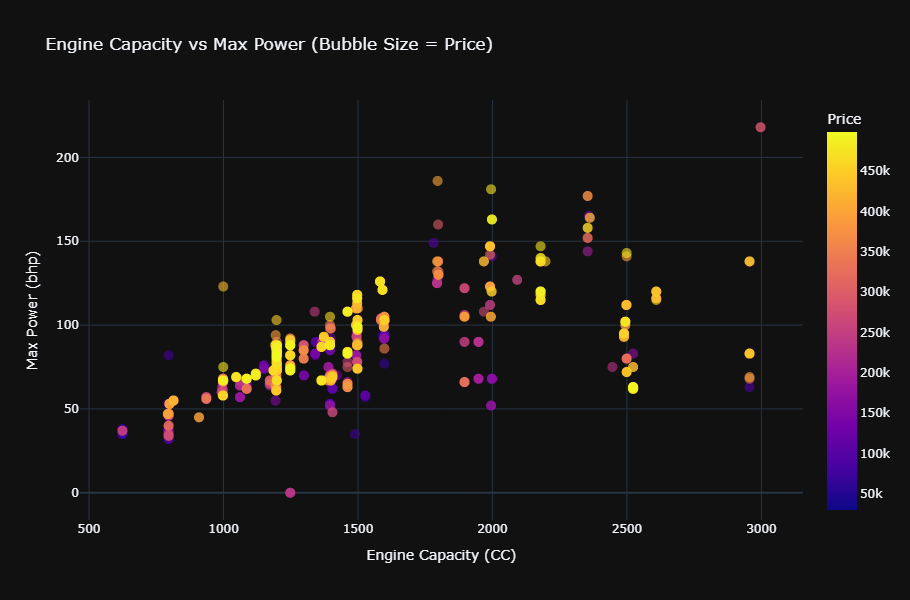

In [92]:
#Max Power vs Engine Capacity (Bubble Chart - size = price) (from v3)
#fig, ax = plt.subplots(figsize=(8, 5))
filtered_cars1=filtered_cars.sort_values(by="Price",ascending=True)

max_power=px.scatter(
    data_frame=filtered_cars1,
    x='Engine', 
    y='Max Power',
    color='Price', 
    size="Price",
    size_max=55,
    hover_name='Car_Name',
    height=600,
    template="plotly_dark",
    opacity=0.6,
    title=('Engine Capacity vs Max Power (Bubble Size = Price)'),
    labels={
        'Engine':"Engine Capacity (CC)",
        'Max Power':'Max Power (bhp)'}
   )

max_power.update_traces(marker=dict(size=10))
max_power.show()

In [93]:
top_cars = car_performance.sort_values(by='Price', ascending=False).head(15).copy()
top_cars['formatted_price'] = top_cars['Price'].apply(lambda x: f"₹{x:,.0f}")

print(top_cars[['Car_Name', 'Price', 'Year', 'Kilometer']])

                              Car_Name     Price  Year  Kilometer
170      Volvo XC90 T8 Excellence BSIV  10000000  2017      30000
2938             BMW X7 xDrive 30d DPE   7200000  2020       5000
4952            Audi A6 35 TFSI Matrix   6523000  2019      23600
4950            Audi A6 35 TFSI Matrix   6223000  2019       7800
4766  BMW 6 Series GT 630d Luxury Line   6000000  2018      27000
1071  BMW 6 Series GT 630d Luxury Line   6000000  2018      28156
5258   Mercedes-Benz S-Class S 350 CDI   6000000  2017      37000
4101  BMW 6 Series GT 630d Luxury Line   6000000  2018      28156
136    Mercedes-Benz S-Class S 350 CDI   6000000  2017      37000
7713   Mercedes-Benz S-Class S 350 CDI   6000000  2017      37000
4951            Audi A6 35 TFSI Matrix   5923000  2019      11500
148    Mercedes-Benz S-Class S 350 CDI   5850000  2017      47000
6258  BMW 6 Series GT 630d Luxury Line   5830000  2018      30000
7596  BMW 6 Series GT 630d Luxury Line   5830000  2018      30000
139       

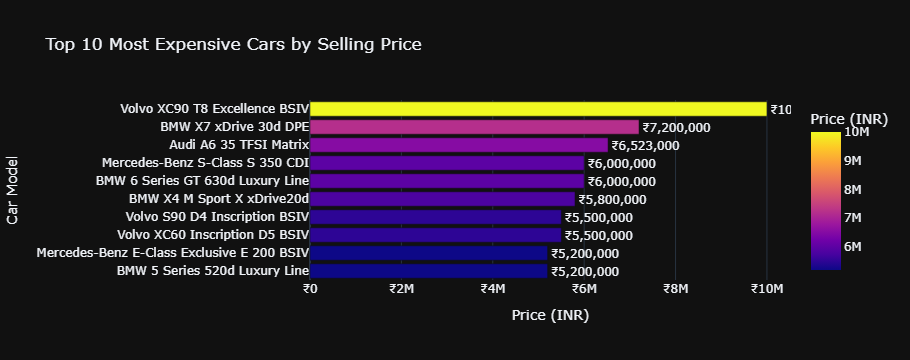

In [94]:
import plotly.express as px

top_cars = car_performance.groupby('Car_Name', as_index=False)['Price'].max().sort_values('Price', ascending=False).head(10)
top_cars['price_in_lakhs'] = top_cars['Price'] / 100000

fig = px.bar(
    top_cars.sort_values('Price', ascending=True), # ascending=True so high values are at top in horizontal bar
    x='Price',
    y='Car_Name',
    color="Price",
    orientation='h',
    title='Top 10 Most Expensive Cars by Selling Price',
    labels={'Price': 'Price (INR)', 'Car_Name': 'Car Model'},
    text=top_cars.sort_values('Price', ascending=True)['Price'].apply(lambda x: f"₹{x:,.0f}"),
    template="plotly_dark"
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickprefix='₹', yaxis={'categoryorder':'total ascending'})



In [127]:
dashboard = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=[
        "Cars based on Fuel Type",
        "count of cars in year 2015 based on their manufactured locations",
        "Average Resale Depreciation (%) by Manufacture Year",
        'Top 10 Most Expensive Cars by Selling Price',
        'Selling Price vs. Kilometers Driven by Fuel Type',
        'Engine Capacity vs Max Power (Bubble Size = Price)',
    ],
    horizontal_spacing=0.08,
    vertical_spacing=0.15,
)

In [131]:
import plotly.graph_objects as go
dashboard.add_trace(go.Pie(labels=car_dim_year["Fuel Type"],values=car_dim_year["Year"]),
                   row=1,col=1)

ValueError: Trace type 'pie' is not compatible with subplot type 'xy'
at grid position (1, 1)

See the docstring for the specs argument to plotly.subplots.make_subplots
for more information on subplot types

In [132]:
dashboard.add_trace(go.Bar(x=top_locations["car_counts"],y=top_locations["locations"]),                   
                    row=1,col=2)
dashboard.add_trace(go.Bar(x=new_car_basics["Year"],y=new_car_basics["Depreciation_Pct"]),
                   row=2,col=1)
dashboard.add_trace(go.Bar(x=car_performance["Price"],y=car_performance["Car_Name"]),
                   row=2,col=2)

KeyError: 'locations'

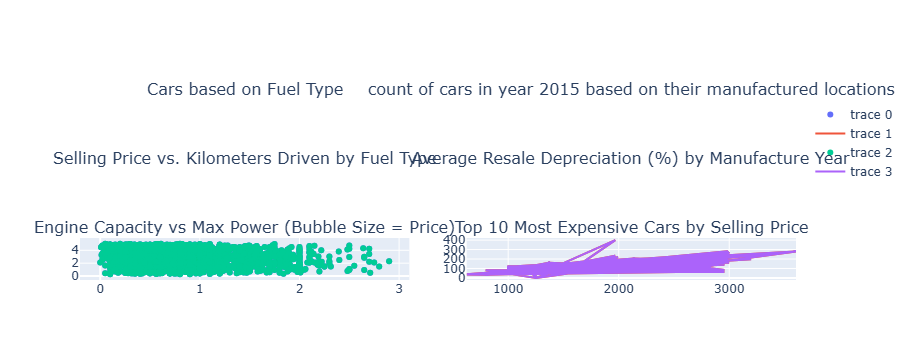

In [133]:
dashboard.add_trace(go.Scatter(x=filtered_cars["Kilometer_Lakhs"],y=filtered_cars["Price_Lakhs"],mode="markers"),
                   row=3,col=1)
dashboard.add_trace(go.Scatter(x=car_performance["Engine"],y=car_performance["Max Power"]),
                   row=3,col=2)

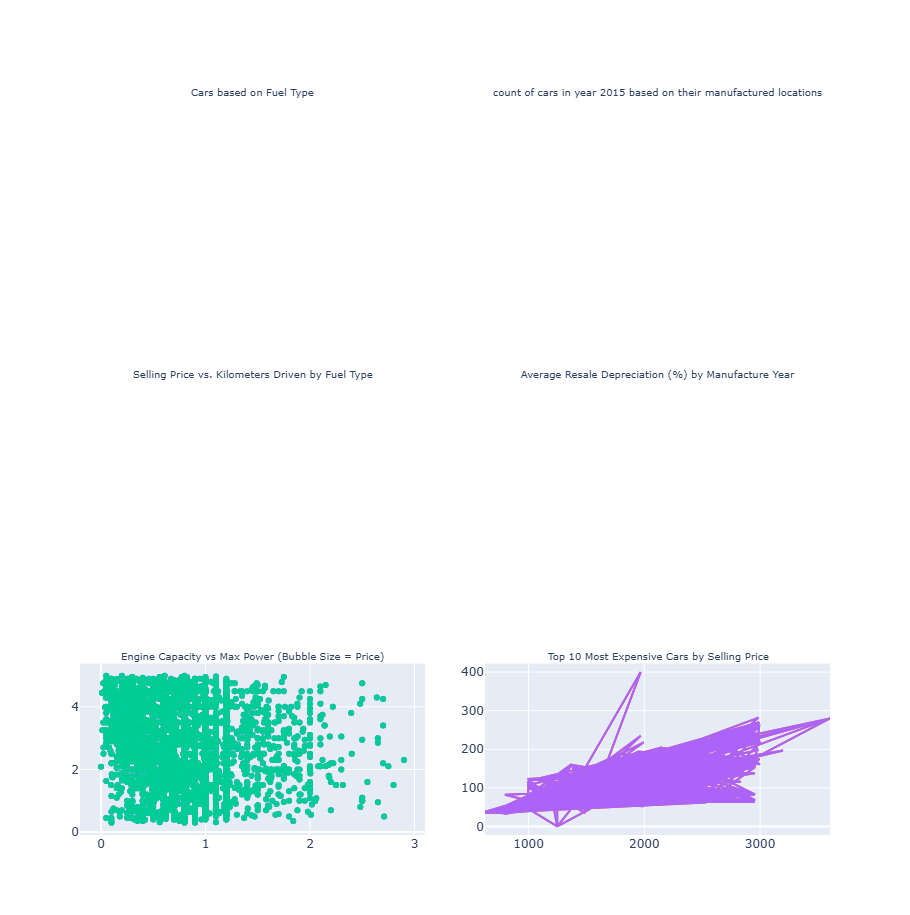

In [134]:
dashboard.update_layout(height=900,width=1300,showlegend=False)
dashboard.update_annotations(font=dict(size=10))
dashboard.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -------------------------------------------------------------------------
# 1. Mock Dataset (Replace this section with your actual 'df' DataFrame)
# -------------------------------------------------------------------------
np.random.seed(42)
n = 300
df = pd.DataFrame(
    {
        "Car_Name": [f"Car {i}" for i in range(n)],
        "Fuel Type": np.random.choice(
            ["Petrol", "Diesel", "CNG", "Electric"], n
        ),
        "Year": np.random.choice(range(2010, 2024), n),
        "location": np.random.choice(
            ["USA", "Germany", "Japan", "India", "UK"], n
        ),
        "selling_price": np.random.randint(5000, 100000, n),
        "km_driven": np.random.randint(5000, 200000, n),
        "engine_capacity": np.random.randint(800, 4000, n),
        "max_power": np.random.randint(60, 500, n),
        "depreciation_pct": np.random.uniform(5, 60, n),
    }
)

# -------------------------------------------------------------------------
# 2. Subplot Layout Setup
# -------------------------------------------------------------------------
dashboard = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=[
        "Cars based on Fuel Type",
        "Count of Cars in Year 2015 based on Manufactured Locations",
        "Average Resale Depreciation (%) by Manufacture Year",
        "Top 10 Most Expensive Cars by Selling Price",
        "Selling Price vs. Kilometers Driven by Fuel Type",
        "Engine Capacity vs Max Power (Bubble Size = Price)",
    ],
    horizontal_spacing=0.08,
    vertical_spacing=0.12,
    specs=[
        [{"type": "domain"}, {"type": "xy"}],  # Pie chart in (1,1) requires domain
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
    ],
)

# -------------------------------------------------------------------------
# 3. Create & Add Traces
# -------------------------------------------------------------------------

# Plot 1: Donut/Pie Chart (Fuel Distribution)
fuel_counts = df["fuel_type"].value_counts()
dashboard.add_trace(
    go.Pie(
        labels=fuel_counts.index,
        values=fuel_counts.values,
        hole=0.4,
        textinfo="percent+label",
    ),
    row=1,
    col=1,
)

# Plot 2: Bar Chart (2015 Cars by Location)
df_2015 = df[df["year"] == 2015]["location"].value_counts().reset_index()
df_2015.columns = ["location", "count"]
dashboard.add_trace(
    go.Bar(
        x=df_2015["location"],
        y=df_2015["count"],
        marker_color="teal",
        text=df_2015["count"],
        textposition="auto",
    ),
    row=1,
    col=2,
)

# Plot 3: Line Chart (Depreciation Trend)
dep_trend = df.groupby("year")["depreciation_pct"].mean().reset_index()
dashboard.add_trace(
    go.Scatter(
        x=dep_trend["year"],
        y=dep_trend["depreciation_pct"],
        mode="lines+markers",
        line=dict(color="crimson", width=2),
    ),
    row=2,
    col=1,
)

# Plot 4: Horizontal Bar Chart (Top 10 Expensive Cars)
top10 = df.nlargest(10, "selling_price").sort_values("selling_price")
dashboard.add_trace(
    go.Bar(
        x=top10["selling_price"],
        y=top10["name"],
        orientation="h",
        marker_color="royalblue",
    ),
    row=2,
    col=2,
)

# Plot 5: Scatter Plot (Price vs. Km Driven grouped by Fuel Type)
for fuel in df["fuel_type"].unique():
    sub_df = df[df["fuel_type"] == fuel]
    dashboard.add_trace(
        go.Scatter(
            x=sub_df["km_driven"],
            y=sub_df["selling_price"],
            mode="markers",
            name=fuel,
            legendgroup="fuel",
            showlegend=False,
        ),
        row=3,
        col=1,
    ),

# Plot 6: Bubble Chart (Engine vs. Power, Size = Price)
dashboard.add_trace(
    go.Scatter(
        x=df["engine_capacity"],
        y=df["max_power"],
        mode="markers",
        marker=dict(
            size=df["selling_price"],
            sizemode="area",
            sizeref=2 * max(df["selling_price"]) / (40**2),  # Scaling factor
            color=df["selling_price"],
            colorscale="Viridis",
            showscale=False,
        ),
        text=df["name"],
    ),
    row=3,
    col=2,
)

# -------------------------------------------------------------------------
# 4. Styling & Display Configuration
# -------------------------------------------------------------------------
dashboard.update_layout(
    height=1200,
    width=1400,
    title_text="<b>Automotive Analytics Dashboard</b>",
    title_x=0.5,
    title_font_size=22,
    template="plotly_white",
    showlegend=False,
)

# Axis labels
dashboard.update_xaxes(title_text="Location", row=1, col=2)
dashboard.update_xaxes(title_text="Manufacture Year", row=2, col=1)
dashboard.update_xaxes(title_text="Selling Price ($)", row=2, col=2)
dashboard.update_xaxes(title_text="Kilometers Driven", row=3, col=1)
dashboard.update_xaxes(title_text="Engine Capacity (cc)", row=3, col=2)

dashboard.update_yaxes(title_text="Car Count", row=1, col=2)
dashboard.update_yaxes(title_text="Avg Depreciation (%)", row=2, col=1)
dashboard.update_yaxes(title_text="Selling Price ($)", row=3, col=1)
dashboard.update_yaxes(title_text="Max Power (bhp)", row=3, col=2)

# Display the dashboard
dashboard.show()